# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/TommySini/RL-book/blob/master/assingments/assignment2.ipynb

*Group members (replace below names with people in your group):* 
- Tommaso Sini
- Anthony Viverito

## Imports

In [40]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by Tommy)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

#### #1 State Space

s = 
$$
\begin{cases} 
(E, i) \quad \text{if employed and working on job i} \\ 
(U, i) \quad \text{if unemployed and no job} \\ 
\end{cases}
$$

#### #2 Action Space

If employed, there is no action to make. So the only true action space is to either accept or reject job $i$ if unemployed. 

A(s) = 
$$
\begin{cases}
(\text{accept}, \text{reject}), \quad s=(U,i) \\ 
\emptyset \qquad \qquad \qquad \quad s=(E,i) \\ 
\end{cases}
$$

#### #3 Transition Function

The transition function is defined as:

$$
P(s' \mid s,a)=
\begin{cases}

1-\alpha, & s=(E,i),\ s'=(E,i) \\

\alpha\, p_j, & s=(E,i),\ s'=(U,j) \\

1-\alpha, & s=(U,i),\ a=\text{accept},\ s'=(E,i) \\

\alpha\, p_j, & s=(U,i),\ a=\text{accept},\ s'=(U,j) \\

p_j, & s=(U,i),\ a=\text{reject},\ s'=(U,j) \\

0, & \text{otherwise}

\end{cases}
$$

#### #4 Reward Function

The reward function can be defined by three different scenarios: 

$$
R(s,a)=
\begin{cases}
\log(w_i), & s=(E,i) \\
\log(w_i), & s=(U,i),\ a=\text{accept} \\
\log(w_0), & s=(U,i),\ a=\text{reject}
\end{cases}
$$

#### #5 Bellman Optimality Equation

Let $\gamma$ be the discount factor.

Employed state $(E,i)$

$$
V^*(E,i)
=
\log(w_i)
+
\gamma \left[
(1-\alpha)V^*(E,i)
+
\alpha \sum_{j=1}^{n} p_j V^*(U,j)
\right].
$$

Unemployed state $(U,i)$

$$
V^*(U,i)
=
\max \Bigg\{

\log(w_i)
+
\gamma \left[
(1-\alpha)V^*(E,i)
+
\alpha \sum_{j=1}^{n} p_j V^*(U,j)
\right],

\log(w_0)
+
\gamma \sum_{j=1}^{n} p_j V^*(U,j)

\Bigg\}.
$$






### Part (B) Answer

In [53]:
import math
from typing import List, Tuple, Literal, Dict

Action = Literal["accept", "reject"]

def solve_job_hopping_value_iteration(
    w0: float,
    wages: List[float],
    probs: List[float],
    alpha: float,
    gamma: float,
    tol: float = 1e-8,
    max_iter: int = 10_000
) -> Tuple[List[float], List[float], List[Action], int]:
   
    """
    Inputs:
      w0: float
        Unemployment wage (must be > 0)
      wages: List[float]
        Job wages [w1, ..., wn] (each must be > 0)
      probs: List[float]
        Job-offer probabilities [p1, ..., pn] (must sum to 1)
      alpha: float
        Probability of losing a job at end of day (0 <= alpha <= 1)
      gamma: float
        Discount factor (0 <= gamma < 1)
      tol: float
        Convergence tolerance for value iteration
      max_iter: int
        Maximum number of iterations

    Outputs:
      V_E: List[float]
        Approximate optimal values V*(E,i) for i=1..n
      V_U: List[float]
        Approximate optimal values V*(U,i) for i=1..n
      policy_U: List[Action]
        Optimal action ("accept" or "reject") for each unemployed-with-offer state (U,i)
      iters: int
        Number of iterations executed
    """

    n: int = len(wages)
    if n == 0 or len(probs) != n:
        raise ValueError("wages and probs must have the same nonzero length.")
    if w0 <= 0 or any(w <= 0 for w in wages):
        raise ValueError("All wages must be > 0 because utility is log(w).")
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("alpha must be in [0,1].")
    if not (0.0 <= gamma < 1.0):
        raise ValueError("gamma must be in [0,1).")
    if abs(sum(probs) - 1.0) > 1e-8:
        raise ValueError("probs must sum to 1.")

    logw: List[float] = [math.log(w) for w in wages]
    logw0: float = math.log(w0)

    V_E: List[float] = [0.0] * n
    V_U: List[float] = [0.0] * n

    iters: int = 0
    for iters in range(1, max_iter + 1):
        V_E_old: List[float] = V_E.copy()
        V_U_old: List[float] = V_U.copy()

        EU: float = sum(probs[j] * V_U_old[j] for j in range(n))

        for i in range(n):
            V_E[i] = logw[i] + gamma * ((1.0 - alpha) * V_E_old[i] + alpha * EU)

        for i in range(n):
            accept: float = logw[i] + gamma * ((1.0 - alpha) * V_E_old[i] + alpha * EU)
            reject: float = logw0 + gamma * EU
            V_U[i] = accept if accept >= reject else reject

        delta: float = 0.0
        for i in range(n):
            delta = max(delta, abs(V_E[i] - V_E_old[i]), abs(V_U[i] - V_U_old[i]))

        if delta < tol:
            break

    EU_final: float = sum(probs[j] * V_U[j] for j in range(n))
    policy_U: List[Action] = []
    for i in range(n):
        accept: float = logw[i] + gamma * ((1.0 - alpha) * V_E[i] + alpha * EU_final)
        reject: float = logw0 + gamma * EU_final
        policy_U.append("accept" if accept >= reject else "reject")

    return V_E, V_U, policy_U, iters


### Part (C) Answer

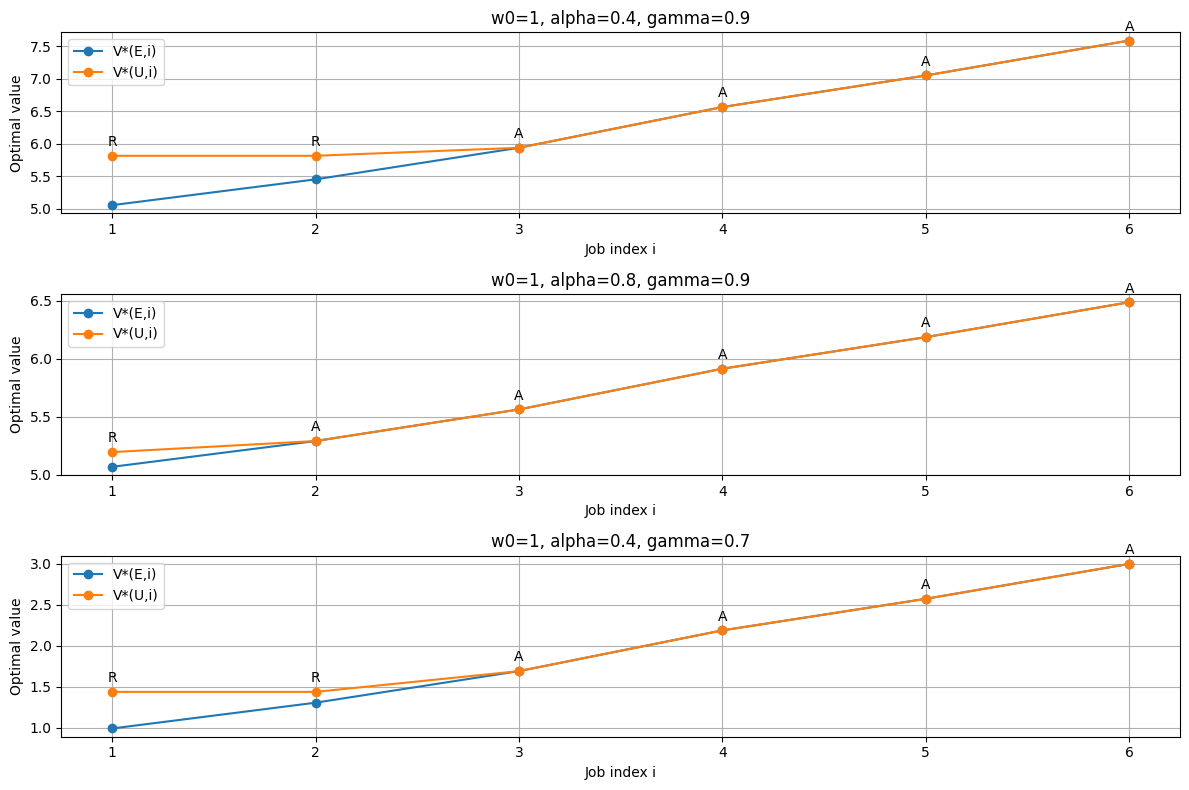

In [62]:

wages = [1.0, 1.2, 1.5, 2.0, 2.5, 3.2]
probs = [1/len(wages)] * len(wages)

def plot_values_on_ax(ax, wages, V_E, V_U, policy_U, title):
    n = len(wages)
    x = list(range(1, n + 1))

    ax.plot(x, V_E, marker="o", label="V*(E,i)")
    ax.plot(x, V_U, marker="o", label="V*(U,i)")

    for i in range(n):
        tag = "A" if policy_U[i] == "accept" else "R"
        ax.annotate(tag, (x[i], V_U[i]), textcoords="offset points", xytext=(0, 7), ha="center")

    ax.set_title(title)
    ax.set_xlabel("Job index i")
    ax.set_ylabel("Optimal value")
    ax.grid(True)
    ax.legend()

param_sets = [
    {"w0": 1, "alpha": 0.4, "gamma": 0.9},
    {"w0": 1, "alpha": 0.8, "gamma": 0.9},
    {"w0": 1, "alpha": 0.4, "gamma": 0.7},
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes = axes.flatten()

for ax, ps in zip(axes, param_sets):
    V_E, V_U, policy_U, iters = solve_job_hopping_value_iteration(
        ps["w0"], wages, probs, ps["alpha"], ps["gamma"]
    )
    plot_values_on_ax(
        ax, wages, V_E, V_U, policy_U,
        title=f"w0={ps['w0']}, alpha={ps['alpha']}, gamma={ps['gamma']}"
    )

plt.tight_layout()
plt.show()


### Part (D) Answer

The optimal policy exhibits a reservation-wage structure. When unemployed with an offer $w_i$, there is a cutoff such that offers below the cutoff are rejected and offers above are accepted. As $\gamma$ increases, the agent becomes more patient and the option value of waiting for better future offers increases, so the cutoff wage rises (more rejections). As $\alpha$ increases, jobs become less durable; accepting a low wage provides less long-run benefit, so the policy becomes more selective and the cutoff tends to increase. Increasing $n$ (with a broader/higher wage menu) increases the option value of remaining unemployed, also leading to a higher cutoff and more selective acceptance.


## Question 2: Two-Stores Inventory Control (Led by Anthony)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [64]:
from dataclasses import dataclass
from typing import Tuple, Dict, Mapping, List

from rl.markov_decision_process import FiniteMarkovDecisionProcess
from rl.distribution import Categorical
from rl.dynamic_programming import value_iteration_result, policy_iteration_result

from scipy.stats import poisson



# State 
@dataclass(frozen=True)
class TwoStoreState:
    on_hand1: int
    on_order1: int  # pipeline that arrives by 6am next morning
    on_hand2: int
    on_order2: int  # pipeline that arrives by 6am next morning

    def ip1(self) -> int:
        """Inventory position for store 1 at 6pm (on_hand + on_order)."""
        return self.on_hand1 + self.on_order1

    def ip2(self) -> int:
        """Inventory position for store 2 at 6pm (on_hand + on_order)."""
        return self.on_hand2 + self.on_order2



# Action 
@dataclass(frozen=True)
class TwoStoreAction:
    order1: int
    order2: int
    transfer: int  # >0 means move that many units from store1 -> store2 

    def has_order1(self) -> bool:
        return self.order1 > 0

    def has_order2(self) -> bool:
        return self.order2 > 0

    def has_transfer(self) -> bool:
        return self.transfer != 0

    def transfer_1_to_2(self) -> int:
        return self.transfer if self.transfer > 0 else 0

    def transfer_2_to_1(self) -> int:
        return -self.transfer if self.transfer < 0 else 0



# Required map type for Finite MDP
# state -> action -> distribution over (next_state, reward)
TwoStoreMDPMap = Mapping[
    TwoStoreState,
    Mapping[TwoStoreAction, Categorical[Tuple[TwoStoreState, float]]]
]


class TwoStoresInventoryMDP(FiniteMarkovDecisionProcess[TwoStoreState, TwoStoreAction]):
    """
    Literal prompt interpretation:

    - Decision time: 6pm each day.
    - At 6pm, each store chooses:
        (i) how much to order from supplier (arrives 36 hours later),
        (ii) how much on-hand inventory to transfer between stores overnight (arrives by 6am next morning).

    Time step from 6pm (today) -> 6pm (tomorrow):
      Overnight to 6am:
        - transfer arrives (on-hand moves)
        - existing on_order arrives (pipeline becomes on-hand available for the day)
      Daytime:
        - demand occurs and consumes on-hand (cannot go below 0)
      6pm:
        - we are in next state; today's order becomes next state's on_order (still in pipeline)

    Capacity constraint at 6pm AFTER ordering:
      on_hand (unchanged by ordering at 6pm) + on_order (already in pipeline) + new_order <= capacity
    """

    def __init__(
        self,
        cap1: int,
        cap2: int,
        lam1: float,
        lam2: float,
        holding_cost1: float,
        holding_cost2: float,
        stockout_cost1: float,
        stockout_cost2: float,
        supplier_fixed_cost: float,
        transfer_fixed_cost: float
    ):
        self.cap1 = cap1
        self.cap2 = cap2

        self.lam1 = lam1
        self.lam2 = lam2

        self.h1 = holding_cost1
        self.h2 = holding_cost2

        self.p1 = stockout_cost1
        self.p2 = stockout_cost2

        self.supplier_fixed_cost = supplier_fixed_cost
        self.transfer_fixed_cost = transfer_fixed_cost

        self.poisson1 = poisson(lam1)
        self.poisson2 = poisson(lam2)

        super().__init__(self.get_action_transition_reward_map())

    # Helpers for Poisson tail handling
    @staticmethod
    def _p_ge_k(distr, k: int) -> float:
        """P(D >= k) = 1 - F(k-1)."""
        return 1.0 - distr.cdf(k - 1)

    @staticmethod
    def _tail_mean_conditional(distr, lam: float, k: int) -> float:
        """
        E[D | D >= k] for Poisson(lam), using:
          E[D * 1_{D>=k}] = lam * P(D >= k-1)
          => E[D | D>=k] = lam * P(D>=k-1) / P(D>=k)
        """
        p_ge_k = TwoStoresInventoryMDP._p_ge_k(distr, k)
        if p_ge_k <= 0.0:
            return float(lam)
        p_ge_km1 = TwoStoresInventoryMDP._p_ge_k(distr, k - 1)
        return lam * p_ge_km1 / p_ge_k

    # Enumerate all states 
    def all_states(self) -> List[TwoStoreState]:
        states: List[TwoStoreState] = []
        for h1 in range(self.cap1 + 1):
            for o1 in range(self.cap1 + 1 - h1):
                for h2 in range(self.cap2 + 1):
                    for o2 in range(self.cap2 + 1 - h2):
                        states.append(TwoStoreState(h1, o1, h2, o2))
        return states

    # Feasible actions from a state 
    def valid_actions(self, s: TwoStoreState) -> List[TwoStoreAction]:
        actions: List[TwoStoreAction] = []

        # Transfer is ON-HAND ONLY:
        # - If transfer > 0: must have enough on_hand1
        # - If transfer < 0: must have enough on_hand2 (i.e. -transfer <= on_hand2)
        t_min = -s.on_hand2
        t_max = s.on_hand1

        for t in range(t_min, t_max + 1):
            # on_hand after transfer (transfer arrives by 6am, but capacity constraint is at 6pm ordering time;
            # the prompt only constrains inventory position after ordering. Transfer doesn't change total inventory,
            # but it changes per-store on-hand, so we enforce per-store capacity after ordering using post-transfer on-hand.)
            h1_after = s.on_hand1 - t
            h2_after = s.on_hand2 + t

            # Capacity AFTER ordering at 6pm:
            # (on_hand_after_transfer) + (existing on_order) + (new order) <= cap
            max_o1 = self.cap1 - (h1_after + s.on_order1)
            max_o2 = self.cap2 - (h2_after + s.on_order2)

            if max_o1 < 0 or max_o2 < 0:
                continue

            for o1 in range(max_o1 + 1):
                for o2 in range(max_o2 + 1):
                    actions.append(TwoStoreAction(order1=o1, order2=o2, transfer=t))

        return actions

    # Apply overnight effects to compute "available before demand" 
    def available_before_demand(self, s: TwoStoreState, a: TwoStoreAction) -> Tuple[int, int, int, int]:
        """
        Returns:
          avail1: on-hand available for store1 at 6am before demand (after transfer + arrival of existing on_order1)
          next_on_order1: pipeline at next 6pm coming from today's order1
          avail2: on-hand available for store2 at 6am before demand
          next_on_order2: pipeline at next 6pm coming from today's order2
        """
        # Transfer moves ON-HAND ONLY:
        h1_after_transfer = s.on_hand1 - a.transfer
        h2_after_transfer = s.on_hand2 + a.transfer

        # Existing on_order arrives by 6am:
        avail1 = h1_after_transfer + s.on_order1
        avail2 = h2_after_transfer + s.on_order2

        # Today's order enters pipeline; will be "on_order" in next 6pm state
        return avail1, a.order1, avail2, a.order2

    # Reward for an outcome
    def reward_for_outcome(
        self,
        a: TwoStoreAction,
        end1: int,
        end2: int,
        unmet1: float,
        unmet2: float
    ) -> float:
        r = -self.h1 * end1 - self.h2 * end2
        r -= self.p1 * unmet1 + self.p2 * unmet2

        if a.has_order1():
            r -= self.supplier_fixed_cost
        if a.has_order2():
            r -= self.supplier_fixed_cost

        if a.has_transfer():
            r -= self.transfer_fixed_cost

        return r

    # Distribution over (next_state, reward) 
    def transition_reward_distribution(
        self,
        s: TwoStoreState,
        a: TwoStoreAction
    ) -> Categorical[Tuple[TwoStoreState, float]]:

        avail1, next_on_order1, avail2, next_on_order2 = self.available_before_demand(s, a)

        # Demand categories:
        # d = 0..avail-1 are exact demands, d = avail is the tail event "D >= avail"
        def prob_and_unmet(distr, lam: float, avail: int, d: int) -> Tuple[float, float]:
            if avail == 0:
                return 1.0, float(lam)  # D>=0 w.p. 1, unmet = E[D]=lam
            if d < avail:
                return float(distr.pmf(d)), 0.0
            p_tail = float(self._p_ge_k(distr, avail))
            mean_tail = float(self._tail_mean_conditional(distr, lam, avail))
            unmet_cond = max(mean_tail - avail, 0.0)
            return p_tail, unmet_cond

        sr_probs: Dict[Tuple[TwoStoreState, float], float] = {}

        for d1 in range(avail1 + 1):
            p1, unmet1 = prob_and_unmet(self.poisson1, self.lam1, avail1, d1)
            if p1 == 0.0:
                continue
            end1 = 0 if d1 == avail1 else (avail1 - d1)

            for d2 in range(avail2 + 1):
                p2, unmet2 = prob_and_unmet(self.poisson2, self.lam2, avail2, d2)
                if p2 == 0.0:
                    continue
                end2 = 0 if d2 == avail2 else (avail2 - d2)

                prob = p1 * p2
                next_state = TwoStoreState(
                    on_hand1=end1,
                    on_order1=next_on_order1,
                    on_hand2=end2,
                    on_order2=next_on_order2
                )
                reward = self.reward_for_outcome(a, end1, end2, unmet1, unmet2)

                key = (next_state, reward)
                sr_probs[key] = sr_probs.get(key, 0.0) + prob

        return Categorical(sr_probs)

    # Full map required by FiniteMarkovDecisionProcess 
    def get_action_transition_reward_map(self) -> TwoStoreMDPMap:
        d: Dict[TwoStoreState, Dict[TwoStoreAction, Categorical[Tuple[TwoStoreState, float]]]] = {}

        for s in self.all_states():
            a_map: Dict[TwoStoreAction, Categorical[Tuple[TwoStoreState, float]]] = {}
            for a in self.valid_actions(s):
                a_map[a] = self.transition_reward_distribution(s, a)
            d[s] = a_map

        return d


if __name__ == "__main__":
    mdp = TwoStoresInventoryMDP(
        cap1=2,
        cap2=2,
        lam1=1.0,
        lam2=1.0,
        holding_cost1=1.0,
        holding_cost2=1.0,
        stockout_cost1=10.0,
        stockout_cost2=10.0,
        supplier_fixed_cost=2.0,
        transfer_fixed_cost=1.0
    )

    gamma = 0.9

    v_star_vi, pi_star_vi = value_iteration_result(mdp, gamma=gamma)
    print("Value Iteration Optimal Value Function:")
    print(v_star_vi)
    print("\nValue Iteration Optimal Policy:")
    print(pi_star_vi)

    v_star_pi, pi_star_pi = policy_iteration_result(mdp, gamma=gamma)
    print("\nPolicy Iteration Optimal Value Function:")
    print(v_star_pi)
    print("\nPolicy Iteration Optimal Policy:")
    print(pi_star_pi)

Value Iteration Optimal Value Function:
{NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=0)): -110.19372327520799, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=1)): -105.90074134751967, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=2)): -103.0252565302969, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=1, on_order2=0)): -105.90074134751967, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=1, on_order2=1)): -102.60775941983138, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=0, on_hand2=2, on_order2=0)): -102.60775941983138, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=0)): -105.90074134751968, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=1)): -101.60775941983137, NonTerminal(state=TwoStoreState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=2)): -98.68928621925714, NonTerminal(stat

## Question 3: Dynamic Price Optimization (Led by Tommy)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer

Let the state be $(t,m)$ where:

- $t$ = days remaining until Halloween
- $m$ = masks in inventory at the start of the day

Action: choose price $p_i$, where $i \in \{1,\dots,N\}$.

Demand:

$$
D \sim \text{Poisson}(\lambda_i)
$$

Sales are limited by demand and inventory:

$$
S = \min(D,m)
$$

Reward (revenue):

$$
R = p_i \cdot \min(D,m)
$$

Next state:

$$
(t-1,\; m-\min(D,m))
$$

Terminal condition:

$$
V_0(m)=0
$$

Bellman Optimality Equation:

$$
V_t(m)
=
\max_i
\mathbb{E}\Big[
p_i\min(D,m)
+
V_{t-1}\big(m-\min(D,m)\big)
\Big],
\quad D\sim\text{Poisson}(\lambda_i).
$$

Expanded form:

$$
V_t(m)
=
\max_i \left[
\sum_{k=0}^{m-1}
\Big(p_i k + V_{t-1}(m-k)\Big)
e^{-\lambda_i}\frac{\lambda_i^k}{k!}
+
\Big(p_i m + V_{t-1}(0)\Big)
\left(1-\sum_{k=0}^{m-1} e^{-\lambda_i}\frac{\lambda_i^k}{k!}\right)
\right].
$$


### Part (B) Answer

Boundary Case(s)

After Halloween, no more sales can occur, so the value function is zero regardless of remaining inventory:

$$
V_0(m) = 0 \quad \text{for all } m \in \{0,1,\dots,M\}.
$$

Additionally, if inventory is zero, no masks can be sold:

$$
V_t(0) = 0 \quad \text{for all } t.
$$


### Part (C) Answer

In [63]:
import math

def optimal_pricing_dp(
    T: int,
    M: int,
    prices: list[float],
    lambdas: list[float]
) -> tuple[list[list[float]], list[list[int]]]:
    """
    Inputs
      T       > int          # number of selling days (days until Halloween)
      M       > int          # starting / maximum inventory (masks)
      prices  > list[float]  # candidate prices p_i
      lambdas > list[float]  # Poisson means λ_i for each price (same length as prices)

    Outputs
      V       > list[list[float]]  # V[t][m] = optimal expected revenue with t days left, m inventory
      pi      > list[list[int]]    # pi[t][m] = index i of optimal price for state (t,m)
    """
    N = len(prices)
    assert N == len(lambdas), "prices and lambdas must have same length"

    # Boundary: V[0][m] = 0 for all m
    V = [[0.0] * (M + 1) for _ in range(T + 1)]
    pi = [[0] * (M + 1) for _ in range(T + 1)]

    for t in range(1, T + 1):
        for m in range(M + 1):
            best_val = float("-inf")
            best_i = 0

            for i in range(N):
                p = prices[i]
                lam = lambdas[i]

                exp_val = 0.0

                pk = math.exp(-lam)  # P(D=0)
                cdf = 0.0

                for k in range(m):  # k = 0..m-1
                    cdf += pk
                    exp_val += (p * k + V[t - 1][m - k]) * pk
                    pk = pk * lam / (k + 1)  # next pmf

                tail = 1.0 - cdf  # P(D >= m)
                exp_val += (p * m + V[t - 1][0]) * tail

                if exp_val > best_val:
                    best_val = exp_val
                    best_i = i

            V[t][m] = best_val
            pi[t][m] = best_i

    return V, pi


def optimal_price_today(
    pi: list[list[int]],
    prices: list[float],
    t: int,
    m: int
) -> float:
    """
    Inputs
      pi     > list[list[int]]   # policy table from optimal_pricing_dp
      prices > list[float]       # same prices used to build pi
      t      > int               # days remaining
      m      > int               # inventory remaining

    Output
      price  > float             # optimal price to post at start of day
    """
    return prices[pi[t][m]]


# Example
V, pi = optimal_pricing_dp(T=10, M=50, prices=[5.0, 6.0, 7.0], lambdas=[20.0, 15.0, 10.0])
print(optimal_price_today(pi, [5.0, 6.0, 7.0], t=10, m=50))


7.0


## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by Anthony)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer

### A1. Compute $\mathbb{E}[U(W)]$
First, rewrite W

$$
\begin{aligned}
W
&=(1+r)(1-\pi)+(1+R)\pi \\
&=(1+r)-\pi(1+r)+\pi+\pi R \\
&=(1+r)+\pi(R-r).
\end{aligned}
$$

$$
\boxed{W=(1+r)+\pi(R-r)}
$$


$$
\mathbb{E}[U(W)]
=\mathbb{E}\!\left[\frac{1-e^{-aW}}{a}\right]
=\frac{1-\mathbb{E}[e^{-aW}]}{a}
$$

Mean of $W$:

$$
\mathbb{E}[W]=(1+r)+\pi(\mu-r)
$$

Variance of $W$:

$$
\mathrm{Var}(W)=\pi^2\sigma^2
$$

Thus:

$$
W\sim \mathcal{N}(m,v)
$$

where

$$
m=(1+r)+\pi(\mu-r), \quad v=\pi^2\sigma^2.
$$

For a normal random variable:

$$
\mathbb{E}[e^{tW}]
=\exp\!\left(tm+\frac12 t^2 v\right)
$$

Setting $t=-a$:

$$
\mathbb{E}[e^{-aW}]
=\exp\!\left(-am+\frac12 a^2 v\right)
$$

Therefore:

$$
\boxed{
\mathbb{E}[U(W)]
=
\frac{
1-\exp\!\left(
-a\big((1+r)+\pi(\mu-r)\big)
+\frac{a^2}{2}\pi^2\sigma^2
\right)
}{a}
}
$$

### A2. Certainty Equivalent $W_{CE}$

Define:

$$
U(W_{CE})=\mathbb{E}[U(W)]
$$

Second-order approximation:

$$
W_{CE}\approx \mathbb{E}[W]-\frac{a}{2}\mathrm{Var}(W)
$$

Substitute:

$$
\boxed{
W_{CE}\approx (1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2
}
$$

---


### Part (B) Answer

Maximize:

$$
W_{CE}(\pi)=(1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2
$$

First-order condition:

$$
\frac{d}{d\pi}W_{CE}(\pi)=(\mu-r)-a\pi\sigma^2=0
$$

Hence:

$$
\boxed{\pi^*=\frac{\mu-r}{a\sigma^2}}
$$

Second derivative:

$$
\frac{d^2}{d\pi^2}W_{CE}(\pi)=-a\sigma^2<0
$$

### Part (C) Answer

### C1. Absolute Risk Premium

$$
\pi_A:=\mathbb{E}[W]-W_{CE}
$$

$$
\begin{aligned}
\pi_A
&\approx
\Big((1+r)+\pi(\mu-r)\Big)
-
\Big((1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2\Big) \\
&=\frac{a}{2}\pi^2\sigma^2
\end{aligned}
$$

$$
\boxed{\pi_A\approx \frac{a}{2}\pi^2\sigma^2}
$$

---

### C2. Small-Variance Approximation

$$
\boxed{\pi_A \approx \frac{a}{2}\pi^2\sigma^2}
$$


### Part (D) Answer

Given:

$$
r=0.02,\qquad \mu=0.08,\qquad \sigma^2=0.04,\qquad a=3
$$

### D1. Optimal Allocation

$$
\pi^*=\frac{0.08-0.02}{3\cdot0.04}
=\frac{0.06}{0.12}
=\boxed{0.5}
$$

---

### D2. Certainty Equivalent

$$
\begin{aligned}
W_{CE}
&\approx 1.02+0.5(0.06)-\frac{3}{2}(0.25)(0.04) \\
&=1.05-0.015 \\
&=\boxed{1.035}
\end{aligned}
$$

---

### D3. Risk Premium

$$
\pi_A=\frac{3}{2}(0.25)(0.04)=\boxed{0.015}
$$

---

### D4. Interpretation

$$
\pi^*=\frac{\mu-r}{a\sigma^2}
$$

- $\pi^*$ decreases as risk aversion $a$ increases.
- $\pi^*$ decreases as variance $\sigma^2$ increases.

$$
\pi_A=\frac{a}{2}\pi^2\sigma^2
$$

- Risk premium increases with $a$.
- Risk premium increases with $\sigma^2$.

### Part (E) answer 

Assume the risky return is no longer Normal. Instead,

$$
R \sim \mathrm{Uniform}[\alpha,\beta],
$$

and wealth is still

$$
W=(1+r)(1-\pi)+(1+R)\pi = (1+r)+\pi(R-r).
$$

---

### Step 1: Identify the distribution (and bounds) of \(W\)

Since \(W\) is an affine (linear + constant) function of \(R\), and \(R\) is uniform, \(W\) is also uniform.

Compute the minimum and maximum wealth by plugging in the endpoints of \(R\):

- If $$(R=\alpha),$$

$$
W_{\min} = (1+r)+\pi(\alpha-r).
$$

- If $$(R=\beta),$$

$$
W_{\max} = (1+r)+\pi(\beta-r).
$$

Thus,

$$
W \sim \mathrm{Uniform}[W_{\min}, W_{\max}],
\quad
W_{\min}=(1+r)+\pi(\alpha-r),
\quad
W_{\max}=(1+r)+\pi(\beta-r).
$$

---

### Step 2: Compute \(\mathbb{E}[U(W)]\)

Recall

$$
U(W)=\frac{1-e^{-aW}}{a}.
$$

Using the hint:

$$
\text{If } W\sim \mathrm{Uniform}[W_{\min},W_{\max}], \text{ then }
\mathbb{E}[g(W)]
=
\frac{1}{W_{\max}-W_{\min}}
\int_{W_{\min}}^{W_{\max}} g(w)\,dw.
$$

So

$$
\mathbb{E}[U(W)]
=
\frac{1}{W_{\max}-W_{\min}}
\int_{W_{\min}}^{W_{\max}} \frac{1-e^{-aw}}{a}\,dw.
$$

Pull out constants:

$$
\mathbb{E}[U(W)]
=
\frac{1}{a(W_{\max}-W_{\min})}
\int_{W_{\min}}^{W_{\max}} \left(1-e^{-aw}\right)\,dw.
$$

Compute the integral:

- $$\int 1\,dw = w$$
- $$\int e^{-aw}\,dw = -\frac{1}{a}e^{-aw}$$

Therefore,

$$
\begin{aligned}
\int_{W_{\min}}^{W_{\max}} (1-e^{-aw})\,dw
&=
\left[w+\frac{1}{a}e^{-aw}\right]_{W_{\min}}^{W_{\max}} \\
&=
(W_{\max}-W_{\min})
+\frac{1}{a}\left(e^{-aW_{\max}}-e^{-aW_{\min}}\right).
\end{aligned}
$$

Plug back in:

$$
\begin{aligned}
\mathbb{E}[U(W)]
&=
\frac{1}{a(W_{\max}-W_{\min})}
\left(
(W_{\max}-W_{\min})
+\frac{1}{a}\left(e^{-aW_{\max}}-e^{-aW_{\min}}\right)
\right) \\
&=
\frac{1}{a}
+
\frac{e^{-aW_{\max}}-e^{-aW_{\min}}}{a^2(W_{\max}-W_{\min})}.
\end{aligned}
$$

So the simplified closed form is

$$
\boxed{
\mathbb{E}[U(W)]
=
\frac{1}{a}
+
\frac{e^{-aW_{\max}}-e^{-aW_{\min}}}{a^2\,(W_{\max}-W_{\min})}
}
$$

---

### Step 3: Express fully in terms of \(a,\pi,\alpha,\beta,r\)

First note:

$$
W_{\max}-W_{\min}
=
\left((1+r)+\pi(\beta-r)\right)
-
\left((1+r)+\pi(\alpha-r)\right)
=
\pi(\beta-\alpha).
$$

Also:

$$
W_{\min}=(1+r)+\pi(\alpha-r),
\qquad
W_{\max}=(1+r)+\pi(\beta-r).
$$

Substitute:

$$
\boxed{
\mathbb{E}[U(W)]
=
\frac{1}{a}
+
\frac{
\exp\!\left(-a\big((1+r)+\pi(\beta-r)\big)\right)
-
\exp\!\left(-a\big((1+r)+\pi(\alpha-r)\big)\right)
}{
a^2\,\pi(\beta-\alpha)
}
}
$$

(Assuming $$\pi(\beta-\alpha)\neq 0$$; if $$\pi=0$$ or $$\alpha=\beta$$, then \(W\) is constant and $$\mathbb{E}[U(W)]=U(1+r).$$)
